In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv(r"C:\Users\WEWL\OneDrive - Capco\Desktop\ADS Assessment\Data\Classification_train.csv")
print(df.head())

       ID Customer_ID     Month           Name   Age          SSN Occupation  \
0  0x1602   CUS_0xd40   January  Aaron Maashoh    23  821-00-0265  Scientist   
1  0x1603   CUS_0xd40  February  Aaron Maashoh    23  821-00-0265  Scientist   
2  0x1604   CUS_0xd40     March  Aaron Maashoh  -500  821-00-0265  Scientist   
3  0x1605   CUS_0xd40     April  Aaron Maashoh    23  821-00-0265  Scientist   
4  0x1606   CUS_0xd40       May  Aaron Maashoh    23  821-00-0265  Scientist   

  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  ...  Credit_Mix  \
0      19114.12            1824.843333                  3  ...           _   
1      19114.12                    NaN                  3  ...        Good   
2      19114.12                    NaN                  3  ...        Good   
3      19114.12                    NaN                  3  ...        Good   
4      19114.12            1824.843333                  3  ...        Good   

   Outstanding_Debt Credit_Utilization_Ratio     C

C:\Users\WEWL\AppData\Local\Temp\ipykernel_29892\1291722512.py:4: DtypeWarning: Columns (0: Monthly_Balance) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\WEWL\OneDrive - Capco\Desktop\ADS Assessment\Data\Classification_train.csv")


In [2]:
print(df.shape)
x, y = df.shape
print(f"Number of data points: {x*y}")
print(df.describe(include=object))
print(df.describe().T.round(2))

(100000, 28)
Number of data points: 2800000


C:\Users\WEWL\AppData\Local\Temp\ipykernel_29892\3059425259.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include=object))


            ID Customer_ID    Month    Name     Age        SSN Occupation  \
count   100000      100000   100000   90015  100000     100000     100000   
unique  100000       12500        8   10139    1788      12501         16   
top     0x1602   CUS_0xd40  January  Langep      38  #F%$D@*&8    _______   
freq         1           8    12500      44    2833       5572       7062   

       Annual_Income Num_of_Loan   Type_of_Loan Num_of_Delayed_Payment  \
count         100000      100000          88592                  92998   
unique         18940         434           6260                    749   
top         17273.83           3  Not Specified                     19   
freq              16       14386           1408                   5327   

       Changed_Credit_Limit Credit_Mix Outstanding_Debt  \
count                100000     100000           100000   
unique                 4384          4            13178   
top                       _   Standard          1360.45   
freq   

In [3]:
#Doesn't seems important for analysis, keeping customer ID to map customer data to fill NA
df = df.drop(["ID","Month","Name","SSN"], axis=1)

In [4]:
df.dtypes

Customer_ID                     str
Age                             str
Occupation                      str
Annual_Income                   str
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                     str
Type_of_Loan                    str
Delay_from_due_date           int64
Num_of_Delayed_Payment          str
Changed_Credit_Limit            str
Num_Credit_Inquiries        float64
Credit_Mix                      str
Outstanding_Debt                str
Credit_Utilization_Ratio    float64
Credit_History_Age              str
Payment_of_Min_Amount           str
Total_EMI_per_month         float64
Amount_invested_monthly         str
Payment_Behaviour               str
Monthly_Balance              object
Credit_Score                    str
dtype: object

In [5]:
#Converting Credit Age to int from object 

import re
def convert_credit_history(text):
    if pd.isna(text):
        return np.nan
    
    match = re.search(r"(\d+)\s+Years?\s+and\s+(\d+)\s+Months?", str(text))
    if match:
        years = int(match.group(1))
        months = int(match.group(2))
        return years * 12 + months
    
    return np.nan

df["Credit_History_Age"] = df["Credit_History_Age"].apply(convert_credit_history)

In [6]:
#Converting numerical values from objects to int/floats 
numeric_cols = [
   'Age','Annual_Income','Monthly_Inhand_Salary','Num_Bank_Accounts','Num_Credit_Card','Interest_Rate','Num_of_Loan','Delay_from_due_date','Num_of_Delayed_Payment','Changed_Credit_Limit','Num_Credit_Inquiries','Outstanding_Debt','Credit_Utilization_Ratio','Credit_History_Age','Total_EMI_per_month','Amount_invested_monthly','Monthly_Balance'
]

for col in numeric_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].str.rstrip("_")
    df[col] = df[col].str.replace(",", "", regex=False)
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [7]:
df.dtypes

Customer_ID                     str
Age                           int64
Occupation                      str
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                   int64
Type_of_Loan                    str
Delay_from_due_date           int64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                      str
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Age          float64
Payment_of_Min_Amount           str
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour               str
Monthly_Balance             float64
Credit_Score                    str
dtype: object

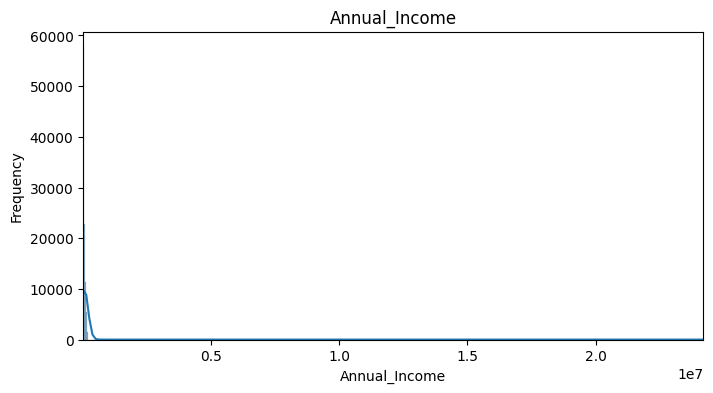

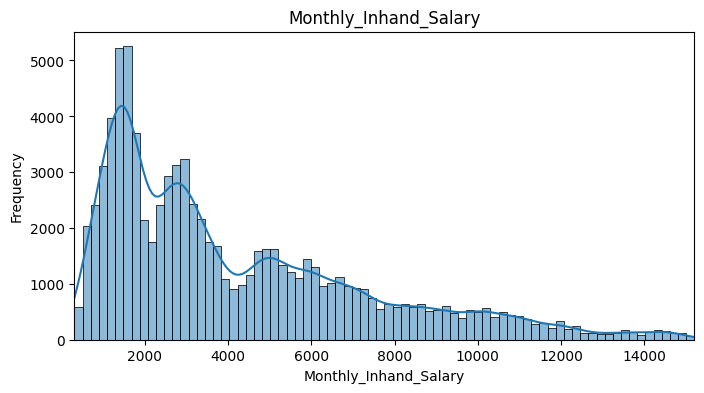

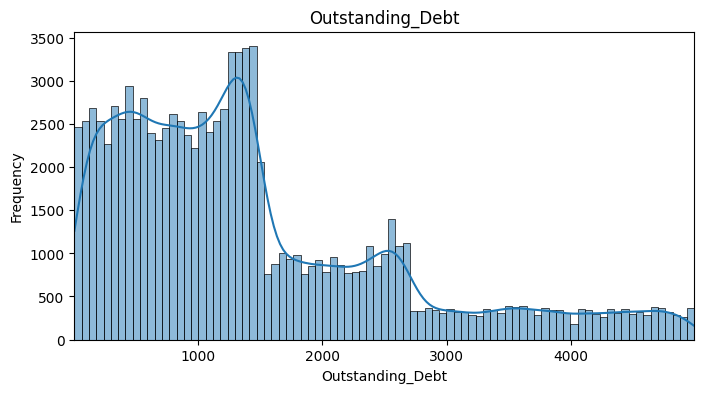

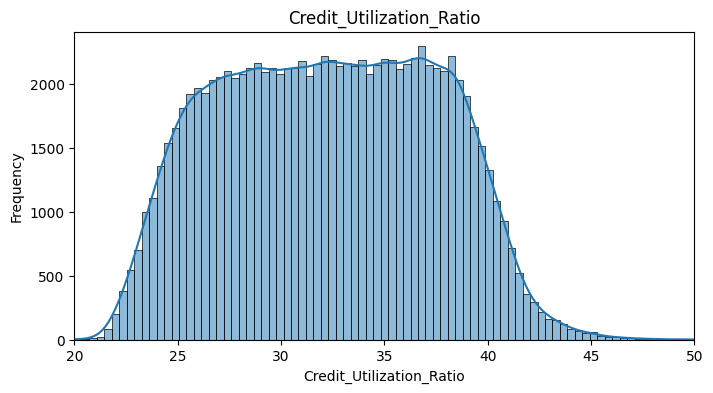

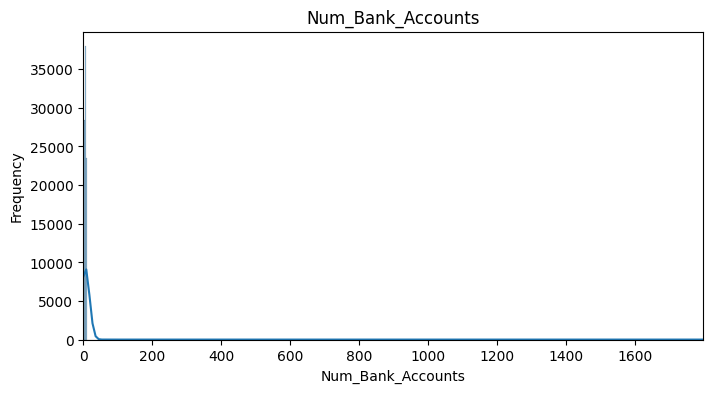

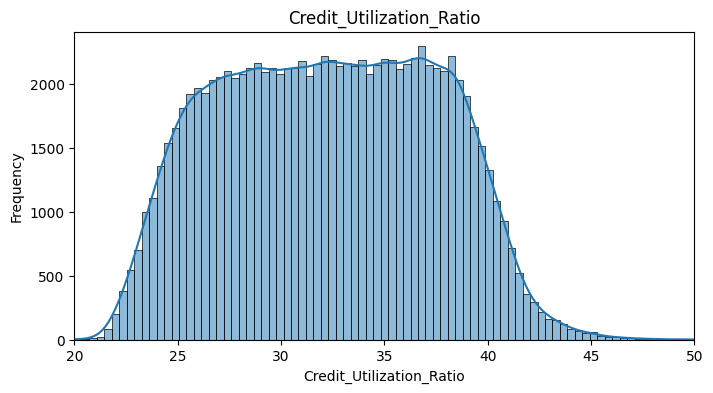

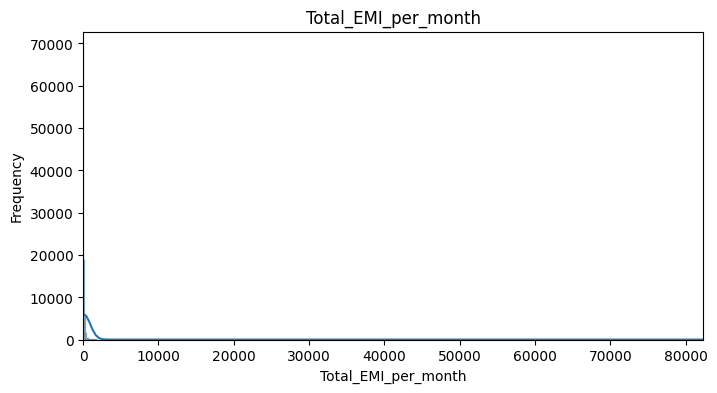

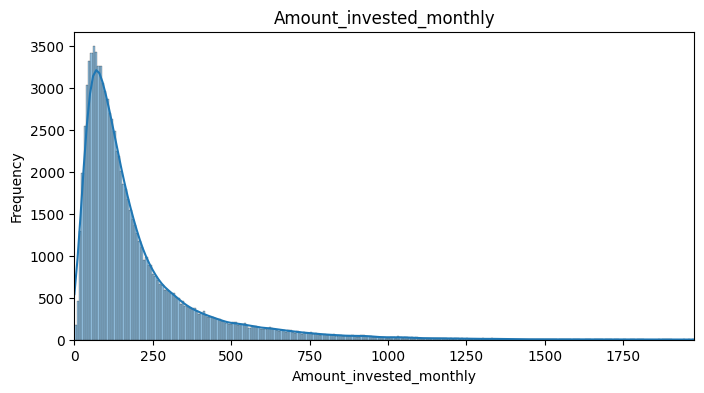

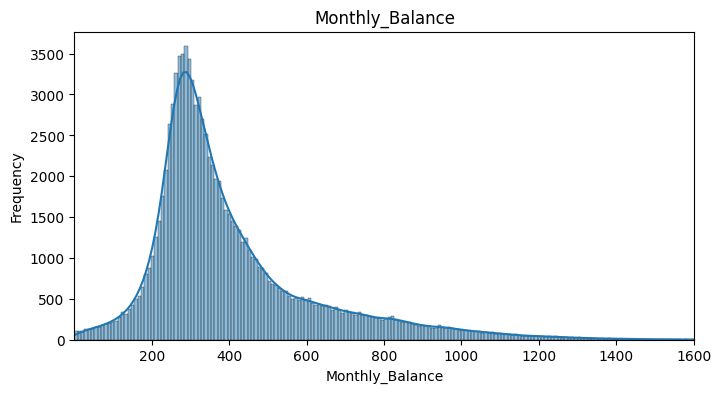

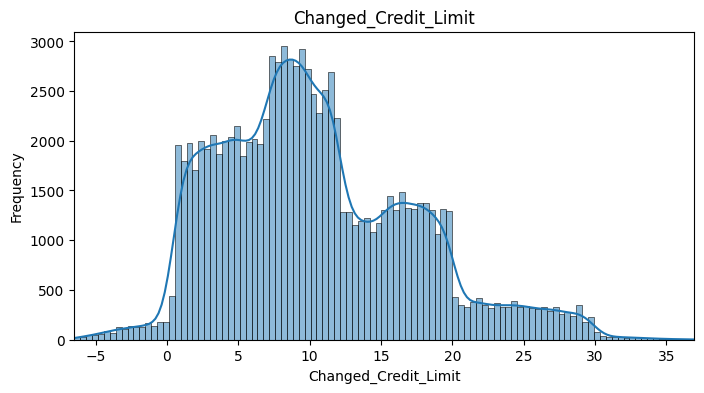

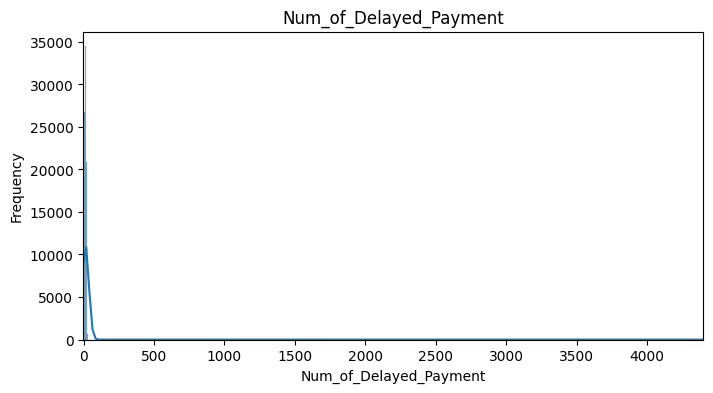

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_distribution(column, title):
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(title)
    plt.xlim(df[column].min(), df[column].dropna().max())
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

plot_distribution("Annual_Income","Annual_Income")
plot_distribution("Monthly_Inhand_Salary","Monthly_Inhand_Salary")
plot_distribution("Outstanding_Debt","Outstanding_Debt")
plot_distribution("Credit_Utilization_Ratio","Credit_Utilization_Ratio")
plot_distribution("Num_Bank_Accounts","Num_Bank_Accounts")
plot_distribution("Credit_Utilization_Ratio","Credit_Utilization_Ratio")
plot_distribution("Total_EMI_per_month","Total_EMI_per_month")
plot_distribution("Amount_invested_monthly","Amount_invested_monthly")
plot_distribution("Monthly_Balance","Monthly_Balance")
plot_distribution("Changed_Credit_Limit","Changed_Credit_Limit")
plot_distribution("Num_of_Delayed_Payment","Num_of_Delayed_Payment")

In [9]:
null_count = df.isnull().sum()
print(null_count)
print(f"There is {null_count.sum()} null data points in the data")

Customer_ID                     0
Age                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit         2091
Num_Credit_Inquiries         1965
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      8784
Payment_Behaviour               0
Monthly_Balance              1209
Credit_Score                    0
dtype: int64
There is 56491 null data points in the data


In [10]:
def number_loans(df):
    df["no_of_loan"] = df["Type_of_Loan"].fillna("").apply(
        lambda x: 0 if x.strip() == "" else x.count(",") + 1
    )
    df.drop(["Type_of_Loan", "Num_of_Loan"], axis=1, inplace=True)

number_loans(df)


In [11]:
def clean_group_numeric(series):
    valid = series.dropna()
    if len(valid) < 4:
        return series

    p1 = valid.quantile(0.02)
    p3 = valid.quantile(0.98)
    ipr = p3 - p1

    lower = p1 - 1.5 * ipr
    upper = p3 + 1.5 * ipr
    median_value = valid.median()

    series = series.apply(
        lambda x: median_value if pd.notna(x) and (x < lower or x > upper) else x
    )

    series = series.fillna(median_value)
    return series

numeric_cols=df.select_dtypes(include="number").columns.tolist()

for col in numeric_cols:
    df[col] = df.groupby("Customer_ID")[col].transform(clean_group_numeric)

In [12]:
null_count = df.isnull().sum()
print(null_count)
print(f"There is {null_count.sum()} null data points in the data")

Customer_ID                   0
Age                           0
Occupation                    0
Annual_Income                 0
Monthly_Inhand_Salary       228
Num_Bank_Accounts             0
Num_Credit_Card               0
Interest_Rate                 0
Delay_from_due_date           0
Num_of_Delayed_Payment        5
Changed_Credit_Limit          0
Num_Credit_Inquiries          0
Credit_Mix                    0
Outstanding_Debt              0
Credit_Utilization_Ratio      0
Credit_History_Age           10
Payment_of_Min_Amount         0
Total_EMI_per_month           0
Amount_invested_monthly      15
Payment_Behaviour             0
Monthly_Balance               5
Credit_Score                  0
no_of_loan                    0
dtype: int64
There is 263 null data points in the data


C:\Users\WEWL\AppData\Local\Temp\ipykernel_29892\2664074748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column,palette="flare")


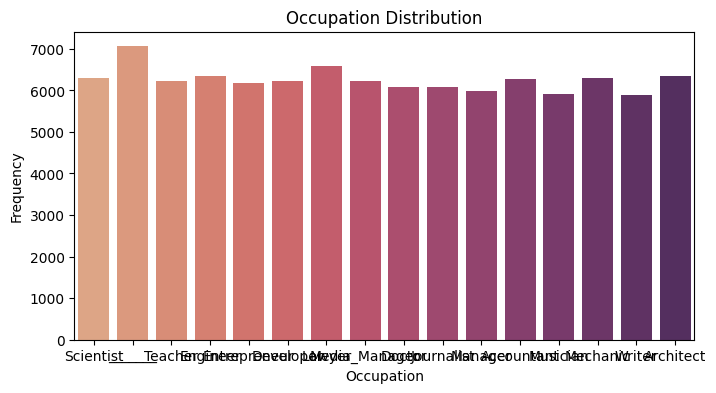

C:\Users\WEWL\AppData\Local\Temp\ipykernel_29892\2664074748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column,palette="flare")


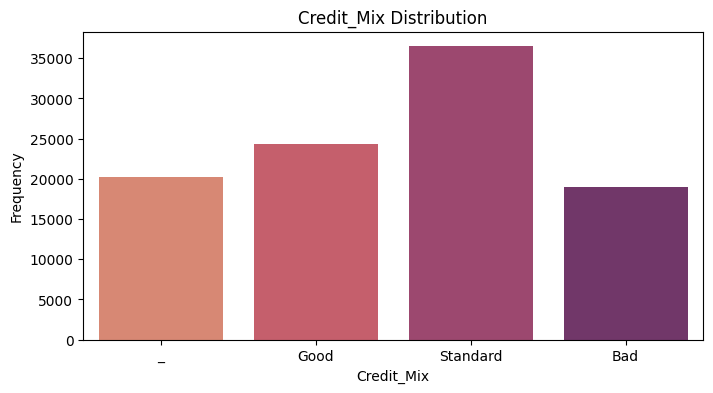

C:\Users\WEWL\AppData\Local\Temp\ipykernel_29892\2664074748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column,palette="flare")


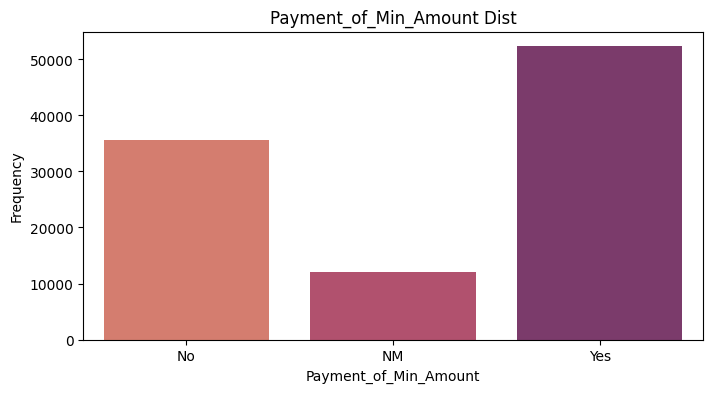

In [13]:
def plot_bar(column, title):
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=column,palette="flare")
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

plot_bar("Occupation", "Occupation Distribution")
plot_bar("Credit_Mix", "Credit_Mix Distribution")
plot_bar("Payment_of_Min_Amount", "Payment_of_Min_Amount Dist")


In [14]:
df["Occupation"] = df["Occupation"].replace("_______", np.nan)
df["Credit_Mix"] = df["Credit_Mix"].replace("_", np.nan)
df["Payment_of_Min_Amount"] = df["Payment_of_Min_Amount"].replace("NM", np.nan)


for col in ["Occupation", "Credit_Mix","Payment_of_Min_Amount"]:
    df[col] = df.groupby("Customer_ID")[col].transform(
        lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x
    )
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\WEWL\AppData\Local\Temp\ipykernel_29892\2664074748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column,palette="flare")


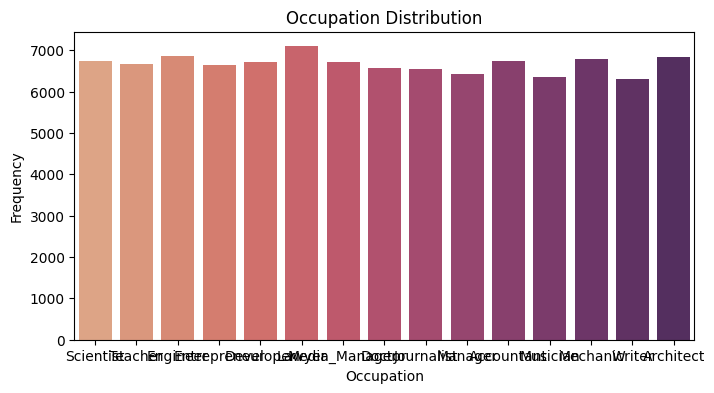

C:\Users\WEWL\AppData\Local\Temp\ipykernel_29892\2664074748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column,palette="flare")


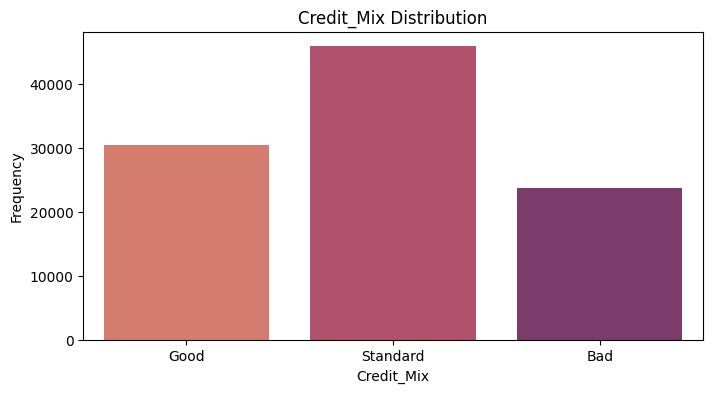

C:\Users\WEWL\AppData\Local\Temp\ipykernel_29892\2664074748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column,palette="flare")


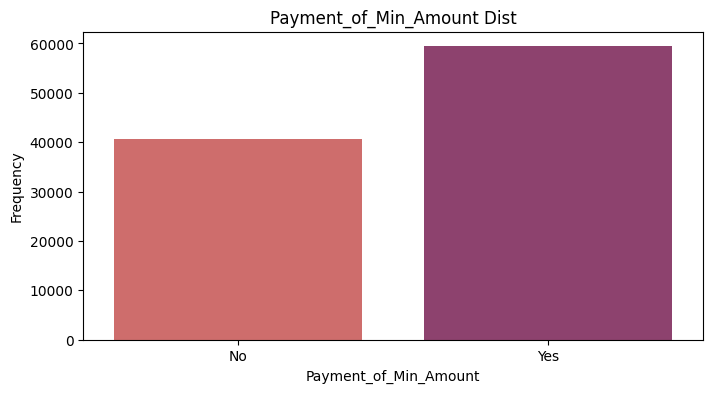

In [15]:
plot_bar("Occupation", "Occupation Distribution")
plot_bar("Credit_Mix", "Credit_Mix Distribution")
plot_bar("Payment_of_Min_Amount", "Payment_of_Min_Amount Dist")

C:\Users\WEWL\AppData\Local\Temp\ipykernel_29892\2664074748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column,palette="flare")


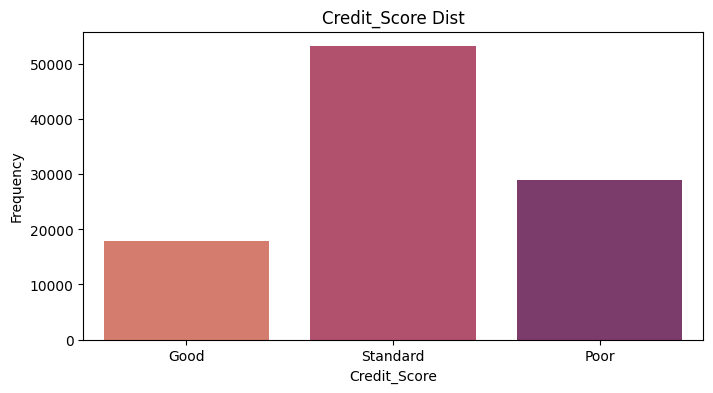

In [16]:
plot_bar("Credit_Score", "Credit_Score Dist")

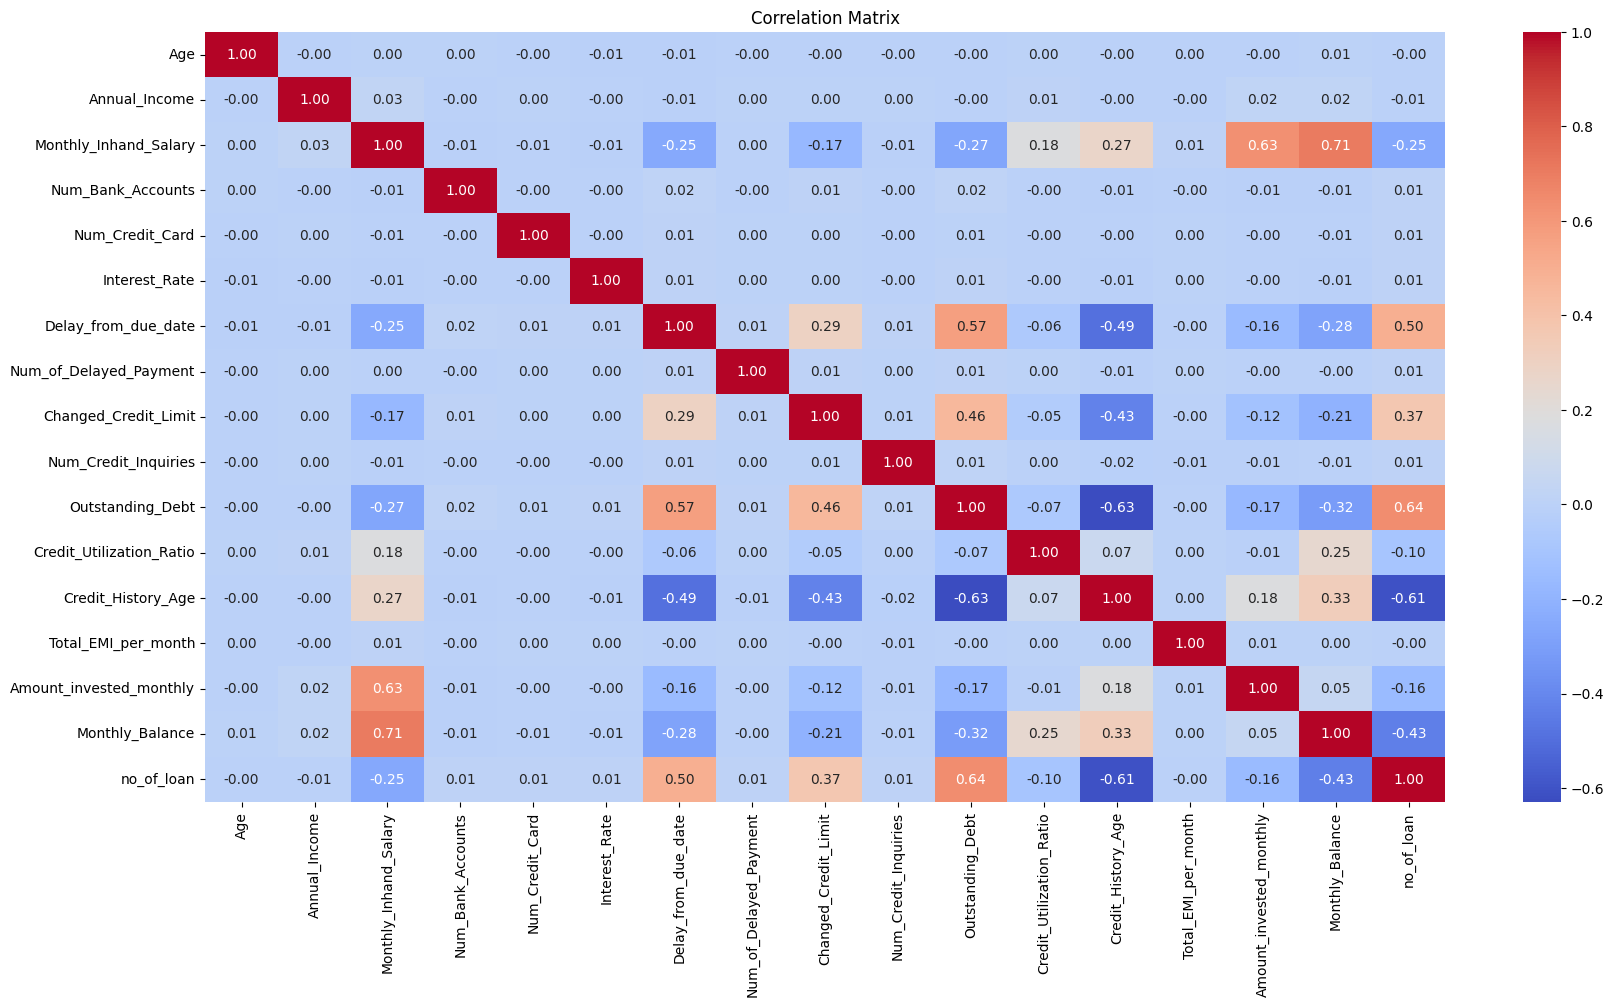

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

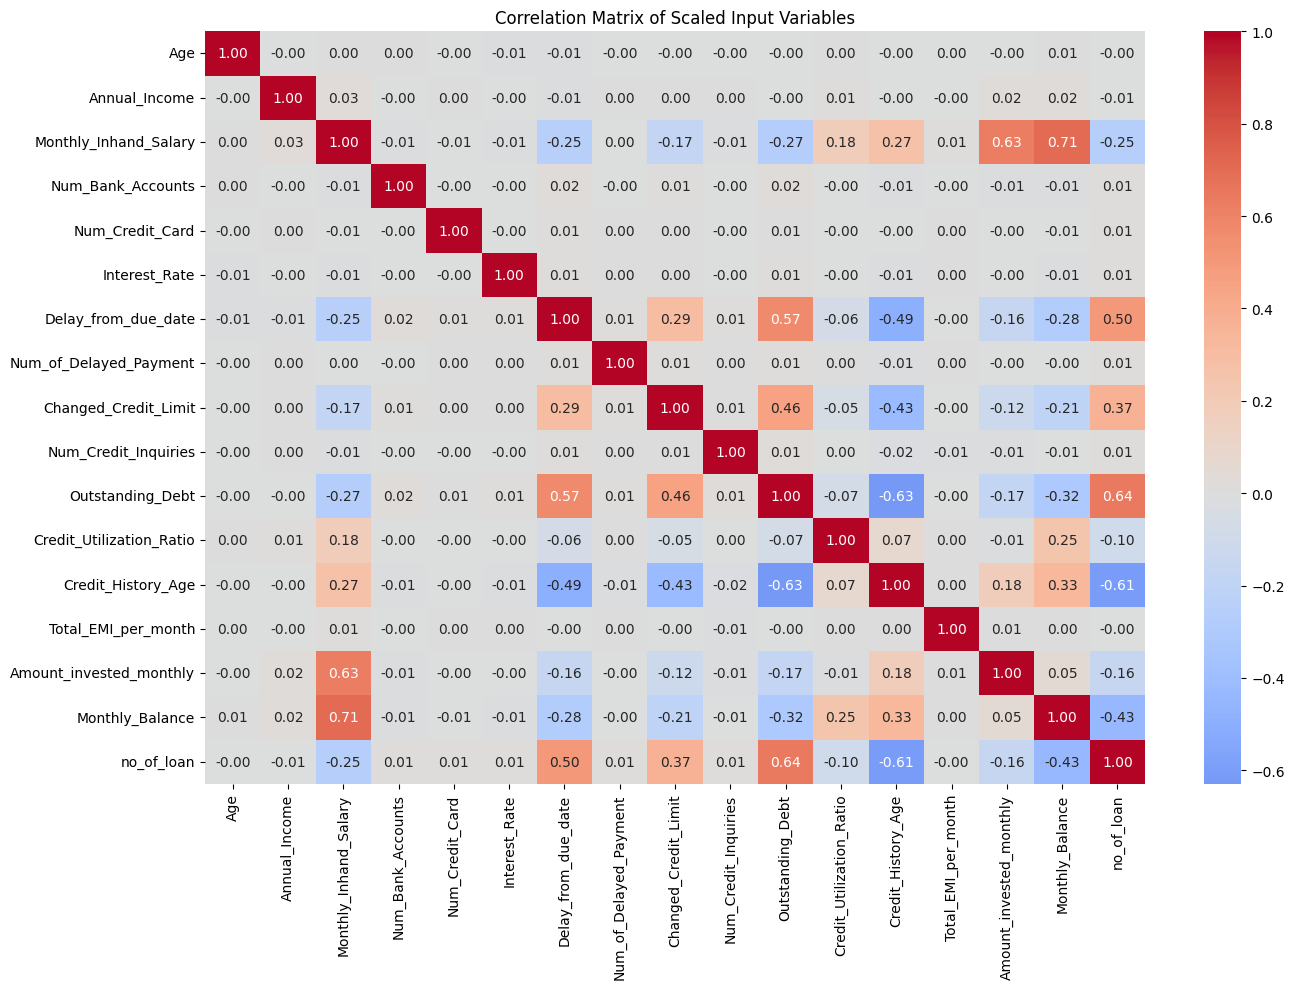

In [18]:
from sklearn.preprocessing import StandardScaler

# Select numeric input variables only
X_numeric = df.drop("Credit_Score", axis=1).select_dtypes(include=["int64", "float64"]).copy()

# Scale them into a new dataframe
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_numeric)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=X_numeric.columns,
    index=X_numeric.index
)

X_scaled.head()

plt.figure(figsize=(14, 10))
corr_matrix = X_scaled.corr()

sns.heatmap(corr_matrix, cmap="coolwarm",annot=True, fmt=".2f", center=0)
plt.title("Correlation Matrix of Scaled Input Variables")
plt.tight_layout()
plt.show()

In [19]:
df=df.dropna(axis=0)
print(df.isnull().sum())
df.shape


Customer_ID                 0
Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
no_of_loan                  0
dtype: int64


(99737, 23)

In [20]:
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace(['!@9#%8'], np.nan)

df["Payment_Behaviour"] = df.groupby("Customer_ID")["Payment_Behaviour"].transform(
    lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x
)

def PB_handling(df):
    df[['Spent', 'Value_Payments']] = df['Payment_Behaviour'].str.split('_', expand=True).iloc[:, [0,2]]
    df.drop(['Payment_Behaviour'], axis=1, inplace=True)

PB_handling(df)


In [21]:
def repl_values(df):
    df['Spent'] = df['Spent'].replace({'High':1, 'Low':0})
    df['Value_Payments'] = df['Value_Payments'].replace({'Small':0, 'Medium':1, 'Large':2})
    df['Credit_Mix'] =df['Credit_Mix'].replace({'Bad':0, 'Standard':1, 'Good':2})
    df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace({'Yes':1, 'No':0})

repl_values(df)


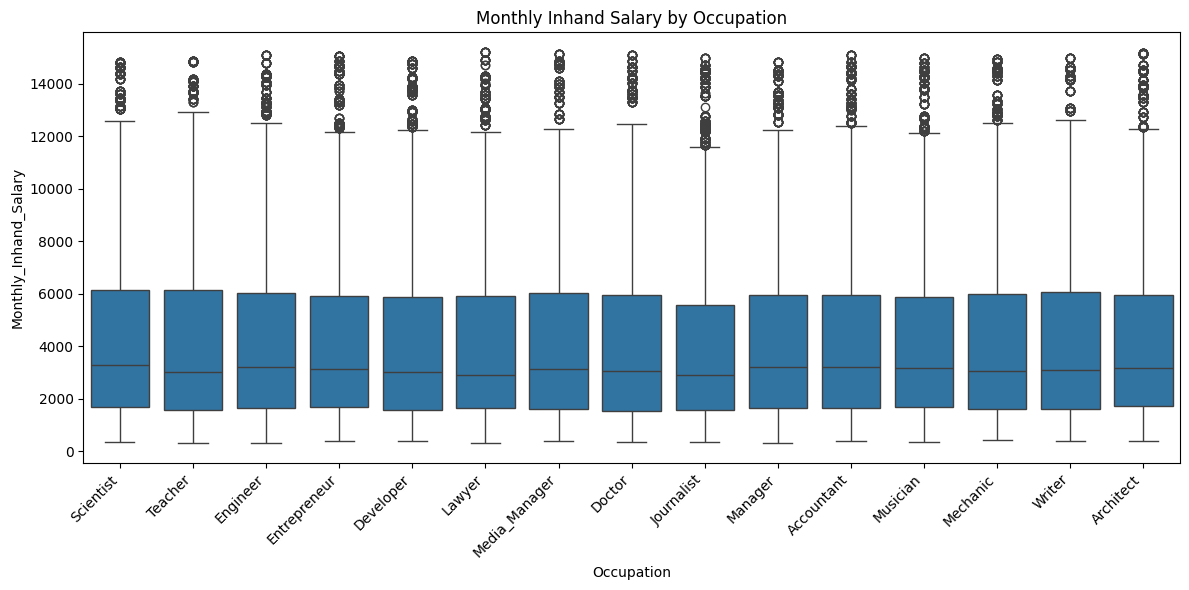

In [22]:
#reduce hot coding complexsiity
occupation_salary = (
    df.groupby("Occupation")["Monthly_Inhand_Salary"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)

occupation_salary

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Occupation", y="Monthly_Inhand_Salary")
plt.title("Monthly Inhand Salary by Occupation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [23]:
df =df.drop("Customer_ID", axis=1)

In [27]:
occupation_test_df = df.copy()

occupation_test_df = pd.get_dummies(
    occupation_test_df,
    columns=["Occupation"],
    drop_first=True
)

print("All occupation dummy columns:")
print([col for col in occupation_test_df.columns if col.startswith("Occupation_")][:20])

X_full = occupation_test_df.drop("Credit_Score", axis=1)

# Keep numeric plus boolean dummy columns
X_full = X_full.select_dtypes(include=["int64", "float64", "uint8", "bool"])

drop_occ_cols = [col for col in X_full.columns if col.startswith("Occupation_")]
print("Occupation columns in X_full:", len(drop_occ_cols))

X_no_occ = X_full.drop(columns=drop_occ_cols, errors="ignore")

print("X_full shape:", X_full.shape)
print("X_no_occ shape:", X_no_occ.shape)



All occupation dummy columns:
['Occupation_Architect', 'Occupation_Developer', 'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Entrepreneur', 'Occupation_Journalist', 'Occupation_Lawyer', 'Occupation_Manager', 'Occupation_Mechanic', 'Occupation_Media_Manager', 'Occupation_Musician', 'Occupation_Scientist', 'Occupation_Teacher', 'Occupation_Writer']
Occupation columns in X_full: 14
X_full shape: (99737, 31)
X_no_occ shape: (99737, 17)


In [31]:
X_full.dtypes[X_full.dtypes == "object"]


Series([], dtype: object)

In [28]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

X_train_no_occ, X_test_no_occ, _, _ = train_test_split(
    X_no_occ, y, test_size=0.2, random_state=42, stratify=y
)

rf_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train_full, y_train)
y_pred_full = rf_pipeline.predict(X_test_full)

print("WITH Occupation")
print("Accuracy:", round(accuracy_score(y_test, y_pred_full), 4))
print(classification_report(y_test, y_pred_full))

rf_pipeline.fit(X_train_no_occ, y_train)
y_pred_no_occ = rf_pipeline.predict(X_test_no_occ)

print("WITHOUT Occupation")
print("Accuracy:", round(accuracy_score(y_test, y_pred_no_occ), 4))
print(classification_report(y_test, y_pred_no_occ))


WITH Occupation
Accuracy: 0.8011
              precision    recall  f1-score   support

        Good       0.72      0.80      0.76      3549
        Poor       0.78      0.85      0.81      5788
    Standard       0.85      0.77      0.81     10611

    accuracy                           0.80     19948
   macro avg       0.78      0.81      0.79     19948
weighted avg       0.81      0.80      0.80     19948

WITHOUT Occupation
Accuracy: 0.7991
              precision    recall  f1-score   support

        Good       0.72      0.81      0.76      3549
        Poor       0.77      0.85      0.81      5788
    Standard       0.85      0.77      0.81     10611

    accuracy                           0.80     19948
   macro avg       0.78      0.81      0.79     19948
weighted avg       0.80      0.80      0.80     19948



In [29]:
print(df.isnull().sum())

Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Monthly_Balance             0
Credit_Score                0
no_of_loan                  0
Spent                       0
Value_Payments              0
dtype: int64


In [31]:
df =df.drop("Occupation", axis=1)

In [33]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# One-hot encode the remaining object columns
X = pd.get_dummies(df.drop("Credit_Score", axis=1), drop_first=True)
y = df["Credit_Score"]

# Encode target for XGBoost
y_encoded = y.map({
    "Poor": 0,
    "Standard": 1,
    "Good": 2
})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("model", LogisticRegression(max_iter=1000))
    ]),
    "Decision Tree": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),
    "Random Forest": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", RandomForestClassifier(random_state=42))
    ]),
    "XGBoost": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", XGBClassifier(
            objective="multi:softprob",
            num_class=3,
            eval_metric="mlogloss",
            random_state=42
        ))
    ])
}

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Mean Accuracy": scores.mean(),
        "CV Std Accuracy": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by="CV Mean Accuracy",
    ascending=False
)

cv_results_df



,Model,CV Mean Accuracy,CV Std Accuracy
2,Random Forest,0.777701,0.001645
3,XGBoost,0.746156,0.001442
1,Decision Tree,0.682287,0.004521
0,Logistic Regression,0.639562,0.001553


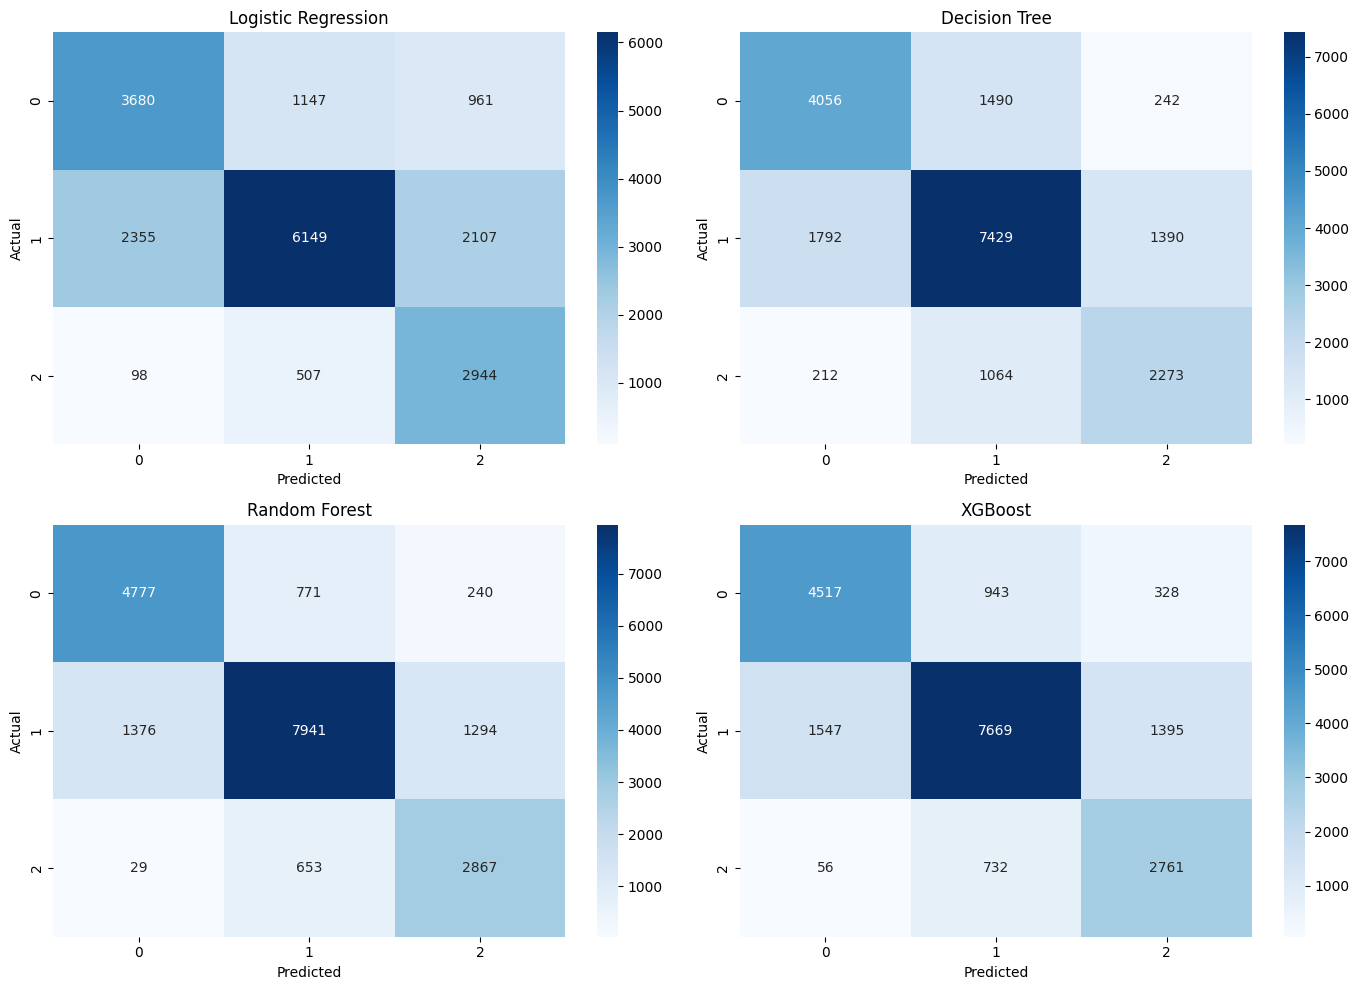

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = sorted(y_test.unique())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=axes[i]
    )

    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

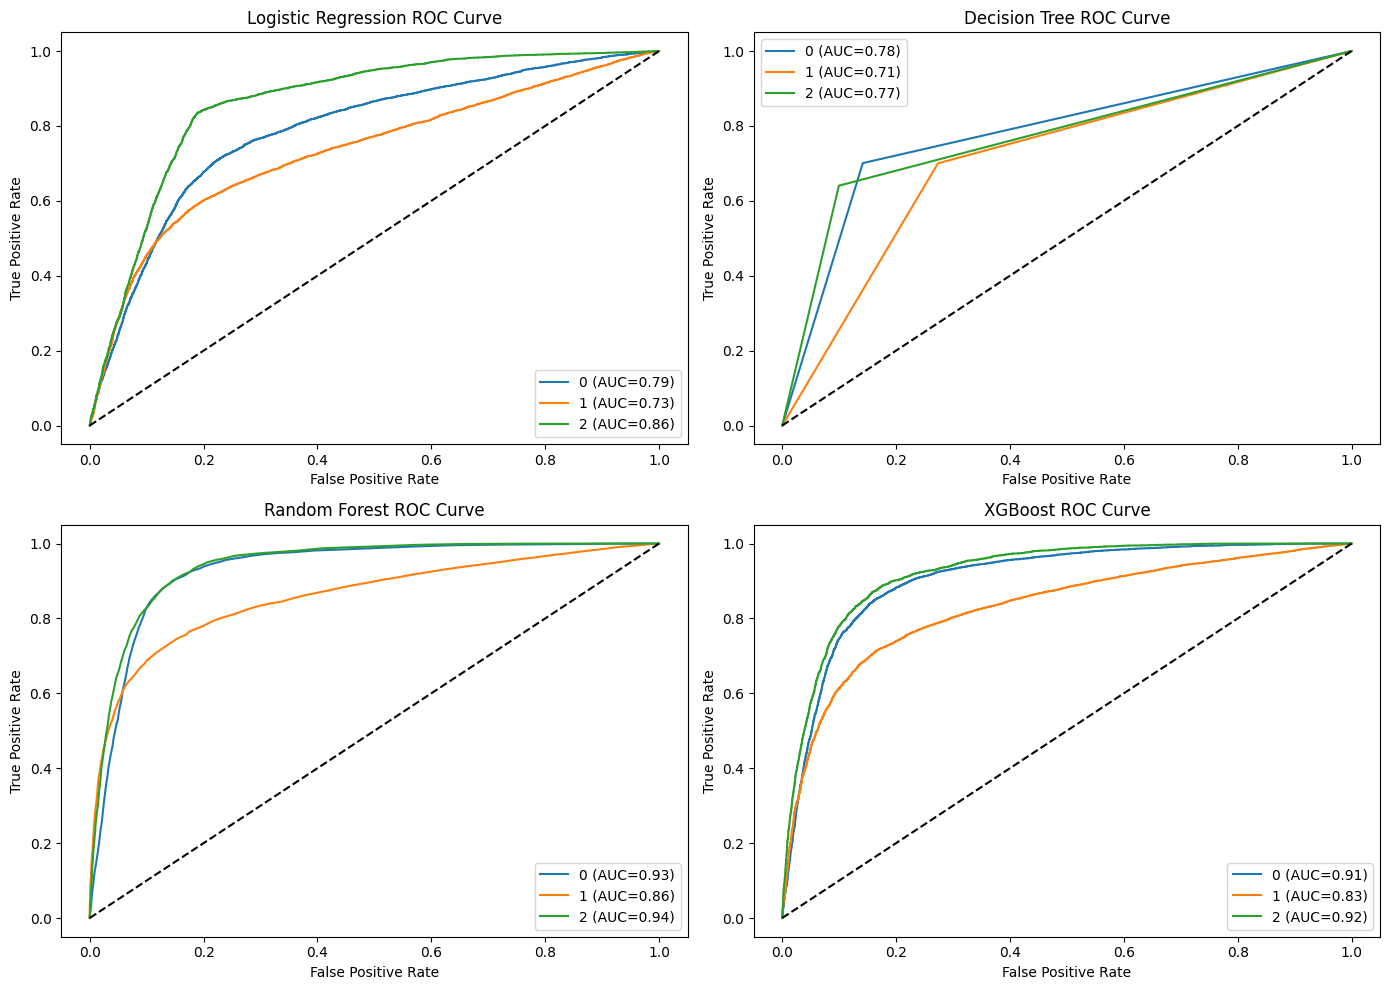

In [36]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    ax = axes[i]

    classes = model.classes_
    y_test_bin = label_binarize(y_test, classes=classes)
    y_score = model.predict_proba(X_test)

    for j, class_name in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, j], y_score[:, j])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc:.2f})")

    ax.plot([0, 1], [0, 1], "k--")
    ax.set_title(f"{name} ROC Curve")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()

plt.tight_layout()
plt.show()

In [37]:
import pandas as pd
from sklearn.metrics import confusion_matrix

labels = sorted(y_test.unique())

def class_sensitivity_specificity(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    results = []

    for i, label in enumerate(labels):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        results.append({
            "Class": label,
            "Sensitivity": sensitivity,
            "Specificity": specificity
        })

    return pd.DataFrame(results)

all_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics_df = class_sensitivity_specificity(y_test, y_pred, labels)
    metrics_df["Model"] = name
    all_results.append(metrics_df)

    print(f"\n{name}")
    print(metrics_df)


Logistic Regression
   Class  Sensitivity  Specificity                Model
0      0     0.635798     0.826766  Logistic Regression
1      1     0.579493     0.822855  Logistic Regression
2      2     0.829529     0.812915  Logistic Regression

Decision Tree
   Class  Sensitivity  Specificity          Model
0      0     0.700760     0.858475  Decision Tree
1      1     0.700123     0.726465  Decision Tree
2      2     0.640462     0.900482  Decision Tree

Random Forest
   Class  Sensitivity  Specificity          Model
0      0     0.825328     0.900777  Random Forest
1      1     0.748374     0.847488  Random Forest
2      2     0.807833     0.906458  Random Forest

XGBoost
   Class  Sensitivity  Specificity    Model
0      0     0.780408     0.886794  XGBoost
1      1     0.722741     0.820606  XGBoost
2      2     0.777966     0.894933  XGBoost


In [41]:
from skopt import BayesSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

search_spaces = {
    "n_estimators": (100, 250),
    "max_depth": (5, 20),
    "min_samples_split": (2, 10),
    "min_samples_leaf": (1, 5)
}

bayes_search = BayesSearchCV(
    estimator=rf,
    search_spaces=search_spaces,
    n_iter=10,
    scoring="roc_auc_ovr",
    cv=3,
    n_jobs=-1,
    random_state=42
)

bayes_search.fit(X_train, y_train)

print("Best Parameters:", bayes_search.best_params_)
print("Best AUC:", bayes_search.best_score_)

Best Parameters: OrderedDict({'max_depth': 19, 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 162})
Best AUC: 0.896554721446628


In [39]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, classification_report

# One-hot encode predictors
X = pd.get_dummies(df.drop("Credit_Score", axis=1), drop_first=True)

# Encode target
y = df["Credit_Score"].map({
    "Poor": 0,
    "Standard": 1,
    "Good": 2
})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

xgb_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ))
])

search_spaces = {
    "model__n_estimators": Integer(100, 300),
    "model__max_depth": Integer(3, 8),
    "model__learning_rate": Real(0.03, 0.2, prior="log-uniform"),
    "model__subsample": Real(0.7, 1.0),
    "model__colsample_bytree": Real(0.7, 1.0)
}

bayes_search = BayesSearchCV(
    estimator=xgb_pipeline,
    search_spaces=search_spaces,
    n_iter=10,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

bayes_search.fit(X_train, y_train)

print("Best CV Score:", bayes_search.best_score_)
print("Best Params:")
print(bayes_search.best_params_)

best_model = bayes_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best CV Score: 0.7605308907496471
Best Params:
OrderedDict({'model__colsample_bytree': 0.8230311876559941, 'model__learning_rate': 0.11931659619655849, 'model__max_depth': 8, 'model__n_estimators': 163, 'model__subsample': 0.9010443844806804})
Test Accuracy: 0.7679466613194306
              precision    recall  f1-score   support

           0       0.76      0.80      0.78      5788
           1       0.83

In [43]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

rf_best = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

rf_best.fit(X_train, y_train)

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


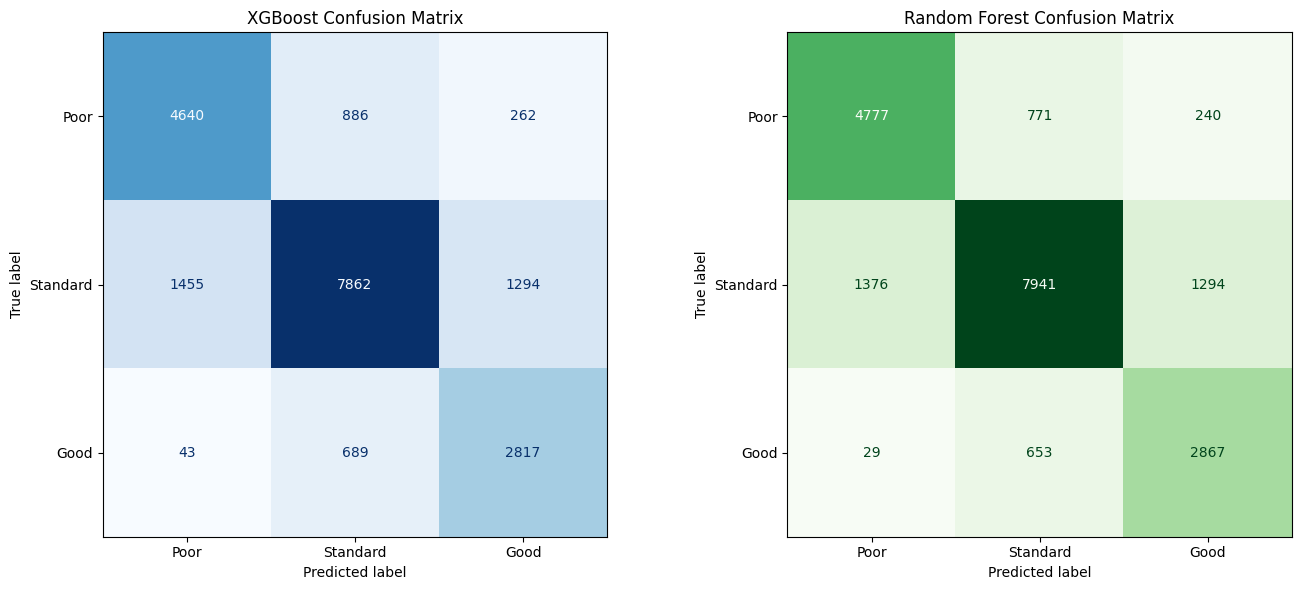

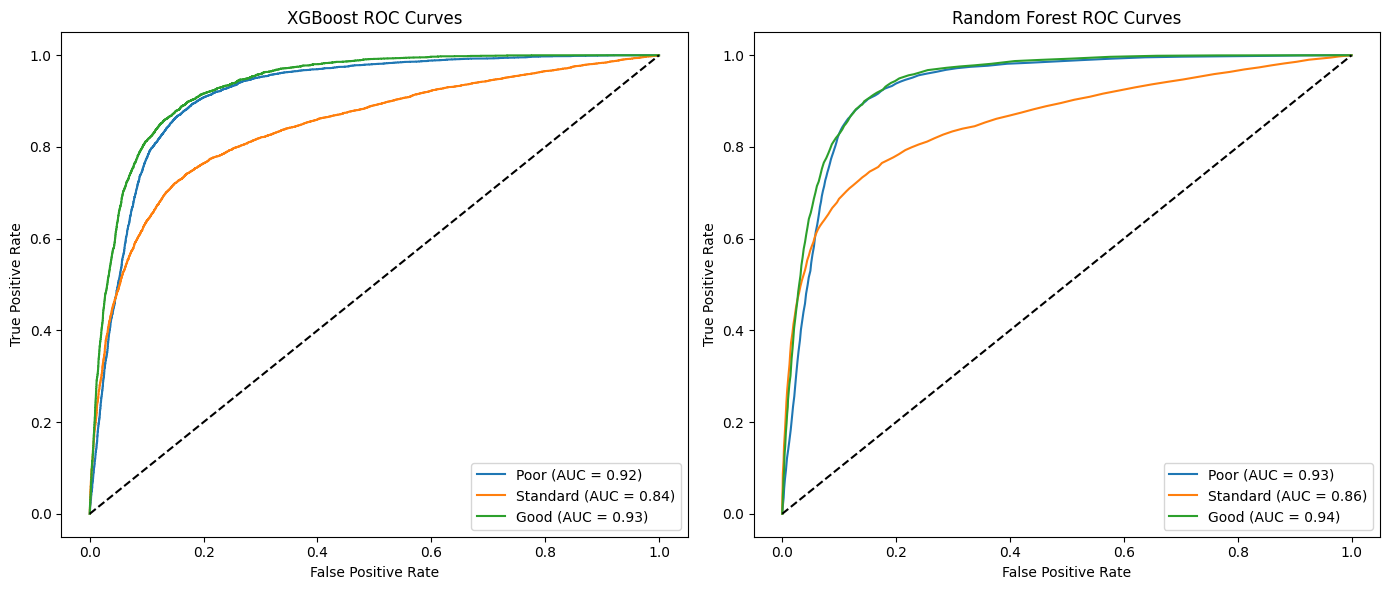

In [45]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Refit Random Forest on the SAME feature set as XGBoost
rf_best = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

rf_best.fit(X_train, y_train)

# Best fitted models
xgb_best = best_model

# Predictions
y_pred_xgb = xgb_best.predict(X_test)
y_pred_rf = rf_best.predict(X_test)

# Probabilities
y_prob_xgb = xgb_best.predict_proba(X_test)
y_prob_rf = rf_best.predict_proba(X_test)

# Class labels
classes = [0, 1, 2]
class_names = {
    0: "Poor",
    1: "Standard",
    2: "Good"
}

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    display_labels=[class_names[c] for c in classes],
    ax=axes[0],
    cmap="Blues",
    colorbar=False
)
axes[0].set_title("XGBoost Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=[class_names[c] for c in classes],
    ax=axes[1],
    cmap="Greens",
    colorbar=False
)
axes[1].set_title("Random Forest Confusion Matrix")

plt.tight_layout()
plt.show()

# ROC curves
y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_xgb[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f"{class_names[classes[i]]} (AUC = {roc_auc:.2f})")

axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_title("XGBoost ROC Curves")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_rf[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f"{class_names[classes[i]]} (AUC = {roc_auc:.2f})")

axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_title("Random Forest ROC Curves")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()
